# Running quantum circuits on QPU devices

In [1]:
# Use Braket SDK Cost Tracking to estimate the cost to run this example
from braket.tracking import Tracker

t = Tracker().start()

In this tutorial we show how to run circuits on QPU devices. We can run our circuit on both the superconducting machine from Rigetti and the ion-trap machine provided by IonQ. As shown below, one can seamlessly swap between different devices without any modifications to the circuit definition, by just re-defining the device object. We also show how to recover results using the unique ARN associated with every quantum task. This tool is useful in order to deal with potential delays if your quantum task sits in the queue for some time waiting for execution. 

In [2]:
# general imports
import matplotlib.pyplot as plt

# magic word for producing visualizations in notebook
%matplotlib inline
import string

# AWS imports: Import Braket SDK modules
from braket.aws import AwsDevice, AwsQuantumTask
from braket.circuits import Circuit, Gate, observables
from braket.device_schema import DeviceActionType
from braket.devices import Devices, LocalSimulator
from braket.parametric import FreeParameter

### Supported gate sets by different devices

First, let us check out the gate set currently supported by our SDK. As with on-demand simulators, you can instantiate a QPU by passing its ARN into `AwsDevice`. Note that the QPU devices only support a subset of these gates.

In [3]:
# print all (the usual suspects) available gates currently available within SDK
gate_set = [attr for attr in dir(Gate) if attr[0] in string.ascii_uppercase]
print("Gate set supported by SDK:\n", gate_set)
print("\n")

# the Rigetti device
rigetti = AwsDevice(Devices.Rigetti.Cepheus1108Q)
supported_gates = rigetti.properties.action[DeviceActionType.OPENQASM].supportedOperations
# print the supported gate set
print("Gate set supported by the Rigetti Cepheus-1-108Q device:\n", supported_gates)
print("\n")

# the IonQ device
ionq = AwsDevice(Devices.IonQ.Forte1)
supported_gates = ionq.properties.action[DeviceActionType.OPENQASM].supportedOperations
# print the supported gate set
print("Gate set supported by the IonQ Aria 1 device:\n", supported_gates)
print("\n")

# the IQM Garnet device
iqm = AwsDevice(Devices.IQM.Garnet)
supported_gates = iqm.properties.action[DeviceActionType.OPENQASM].supportedOperations
# print the supported gate set
print("Gate set supported by the IQM Garnet device:\n", supported_gates)

Gate set supported by SDK:
 ['CCNot', 'CNot', 'CPhaseShift', 'CPhaseShift00', 'CPhaseShift01', 'CPhaseShift10', 'CSwap', 'CV', 'CY', 'CZ', 'ECR', 'GPhase', 'GPi', 'GPi2', 'H', 'I', 'ISwap', 'MS', 'PRx', 'PSwap', 'PhaseShift', 'PulseGate', 'Rx', 'Ry', 'Rz', 'S', 'Si', 'Swap', 'T', 'Ti', 'U', 'Unitary', 'V', 'Vi', 'X', 'XX', 'XY', 'Y', 'YY', 'Z', 'ZZ']


Gate set supported by the Rigetti Cepheus-1-108Q device:
 ['cz', 'xy', 'ccnot', 'cnot', 'cphaseshift', 'cphaseshift00', 'cphaseshift01', 'cphaseshift10', 'cswap', 'h', 'i', 'iswap', 'phaseshift', 'pswap', 'rx', 'ry', 'rz', 's', 'si', 'swap', 't', 'ti', 'x', 'y', 'z', 'barrier']


Gate set supported by the IonQ Aria 1 device:
 ['x', 'y', 'z', 'h', 's', 'si', 't', 'ti', 'v', 'vi', 'rx', 'ry', 'rz', 'cnot', 'swap', 'xx', 'yy']


Gate set supported by the IQM Garnet device:
 ['ccnot', 'cnot', 'cphaseshift', 'cphaseshift00', 'cphaseshift01', 'cphaseshift10', 'cswap', 'swap', 'iswap', 'pswap', 'ecr', 'cy', 'cz', 'xy', 'xx', 'yy', 'zz', 'h', 'i

### Problem: Prepare Bell State

Goal: Prepare maximally entangled Bell state: 
$$\left|0,0\right> \rightarrow \left|\mathrm{Bell}\right> = \frac{1}{\sqrt{2}}\left(\left|0,0\right> + \left|1,1\right>\right).$$

To this end, we build and run the following circuit using a single-qubit Hadamard gate (denoted as ```H```) acting on the first qubit followed by a two-qubit ```CNOT``` gate: 
<div align="center">
<img src="bell_circuit.png" width="500"/>
</div>

### Setup Circuit

In [4]:
# define circuit
bell = Circuit().h(0).cnot(0, 1)

In [5]:
# print circuit
print(bell)

T  : │  0  │  1  │
      ┌───┐       
q0 : ─┤ H ├───●───
      └───┘   │   
            ┌─┴─┐ 
q1 : ───────┤ X ├─
            └───┘ 
T  : │  0  │  1  │


### Local Simulator

First we run our circuit locally, using an exact state-vector simulator. This local simulator is the preferred choice for fast experiments with low to intermediate qubit numbers ($N<20-25$) and essentially unlimited circuit depth. 

In [6]:
# set up device: Local Simulator
device = LocalSimulator()

In [7]:
# run circuit (execute single TASK)
result = device.run(bell, shots=1000).result()
# get measurement shots
counts = result.measurement_counts
# print counts
print(counts)

Counter({'00': 502, '11': 498})


Text(0, 0.5, 'counts')

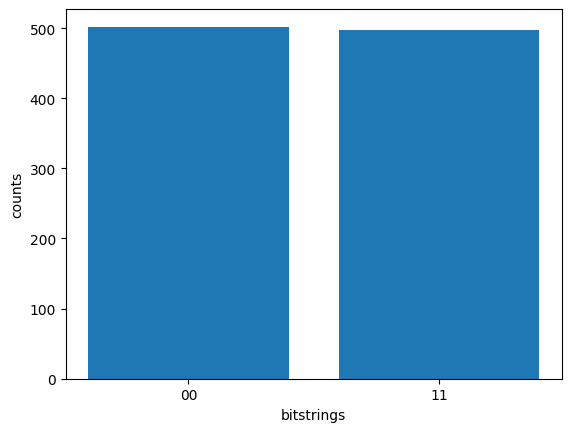

In [8]:
# plot using Counter
plt.bar(counts.keys(), counts.values())
plt.xlabel("bitstrings")
plt.ylabel("counts")

<div class="alert alert-block alert-warning">
    <b>Caution:</b> The sections below will create QPU tasks which will incur a usage fee of about $35 to your AWS account. 
    You can view <a href="https://aws.amazon.com/braket/pricing/" target="_blank">this page</a> for more details on the usage fee.
    We also recommend monitoring the 
    <a href="https://console.aws.amazon.com/billing/home" target="_blank">Billing & Cost Management Dashboard</a> 
    on the AWS console.
</div>

### Quantum Hardware: Rigetti

Next we submit our circuit to the superconducting quantum chip provided by Rigetti. Depending on our position in the queue, we may have to wait for some time till our circuit is actually run. However, thanks to asynchronous execution, we can always come back and recover the results by providing the unique ID associated with every quantum task. 

To exectue your quantum task on a device, your task needs to wait for the device to complete running or already queued quantum tasks. Before submitting a quantum task on a device, you can check the queue depth for the quantum tasks. To check the number of hybrid jobs queued on the device call `device.queue_depth().quantum_tasks`. Here, Priority quantum tasks refer to the tasks submitted as part of a Hybrid Job. These quantum tasks has priority over the Normal quantum tasks. 

In [9]:
# check for the queue_depth for quantum tasks on the selected device
rigetti.queue_depth().quantum_tasks

{<QueueType.NORMAL: 'Normal'>: '0', <QueueType.PRIORITY: 'Priority'>: '0'}

In [10]:
# create a clean circuit with no result type attached.(This is because some result types are only supported when shots=0)
bell = Circuit().h(0).cnot(0, 1)

# add the Z \otimes Z expectation value
bell.expectation(observables.Z(0) @ observables.Z(1))

# run circuit
rigetti_task = rigetti.run(bell, shots=1000)

# get id and status of submitted task
rigetti_task_id = rigetti_task.id
rigetti_status = rigetti_task.state()
# print('ID of task:', rigetti_task_id)
print("Status of quantum task:", rigetti_status)

Status of quantum task: QUEUED


You can check the position of your quantum task in the queue by calling `task.queue_position().queue_position`. The queue position is only returned when the task is in "QUEUED" state, else None is returned. You can also check why the queue position value is not returned by calling calling `task.queue_position().message`. Here, `task` is the variable to which you assign your quantum_task creation.

In [11]:
# let's check the queue position for task created with the rigetti device
rigetti_task.queue_position().queue_position

'1'

The quantum task is submitted and we can regularly (or irregularly) check the status of this quantum task by executing the following cell. You may easily build logic around this query to wait for this quantum task to complete before your code proceeds. 

In [12]:
# print status
status = rigetti_task.state()
print("Status of (reconstructed) quantum task:", status)

Status of (reconstructed) quantum task: COMPLETED


### Quantum Hardware: IonQ

Next, we submit our example Bell state circuit to IonQ. We set the device as `AwsDevice("arn:aws:braket:us-east-1::device/qpu/ionq/Forte-1")`. This quantum task may not readily be executed but enter a queue for this specific machine. While we can interrupt our kernel (and work on something else), we can always recover our results using the unique ID of this quantum task.

Before submitting our quantum task, let's check the queue depth on the device for quantum tasks.

In [13]:
ionq.queue_depth().quantum_tasks

{<QueueType.NORMAL: 'Normal'>: '0', <QueueType.PRIORITY: 'Priority'>: '0'}

In [14]:
# run circuit
ionq_task = ionq.run(bell, shots=100)

# get id and status of submitted quantum task
ionq_task_id = ionq_task.id
ionq_status = ionq_task.state()
# print('ID of quantum task:', ionq_task_id)
print("Status of quantum task:", ionq_status)

Status of quantum task: QUEUED


Let's check the queue position for the submitted quantum task on the device.

In [15]:
# check the queue position
ionq_task.queue_position().queue_position

'1'

In [16]:
# print status
status = ionq_task.state()
print("Status of (reconstructed) quantum task:", status)

Status of (reconstructed) quantum task: QUEUED


## Quantum Hardware: IQM
Finally, the Bell circuit is submitted to the IQM Garnet device.

In [17]:
# run circuit
iqm_task = iqm.run(bell, shots=1000)

# get id and status of submitted quantum task
iqm_task_id = iqm_task.id
iqm_status = iqm_task.state()
# print('ID of quantum task:', iqm_task_id)
print("Status of quantum task:", iqm_status)

Status of quantum task: QUEUED


In addition to the state of the task, you can monitor the progress by the queue position of the task.

In [18]:
# check the queue position
iqm_task.queue_position().queue_position

'1'

### Parametric compilation
When submitting a parametric circuit to a supported QPU, Braket will compile the circuit once and cached the compiled circuit. For the subsequent parameter updates to the same circuit, there is no recompilation which results in faster runtimes. The cached compiled circuits persist until the end of the availability window of the QPU. To learn more about submitting a parametrized task, see the [Amazon Braket developer guide](https://docs.aws.amazon.com/braket/latest/developerguide/braket-submit-tasks-to-braket.html#braket-submit-parametrized-task).

In [19]:
theta = FreeParameter("theta")
parametrized_circuit = Circuit().rx(0, theta)

angle_value = 0.789
pc_task = rigetti.run(parametrized_circuit, shots=100, inputs={"theta": angle_value})

# get status of submitted quantum task
print("Status of quantum task:", pc_task.state())

Status of quantum task: QUEUED


### Quantum Task Recovery

By simply grabbing the unique quantum task ID associated with the quantum tasks we have submitted above, we can recover this quantum task at any point in time and (once the status is completed) visualize and analyze the corresponding results. Note that apart from other metadata, you can retrieve the compiled circuit that was actually run on the Rigetti device. More information about the compiling process can be found [here](https://pyquil-docs.rigetti.com/en/v2.22.0/compiler.html#partial). 

Status of (reconstructed) quantum task: COMPLETED


1000 shots taken on machine arn:aws:braket:us-west-1::device/qpu/rigetti/Cepheus-1-108Q.

The compiled circuit is:
 PRAGMA INITIAL_REWIRING "NAIVE"
DECLARE ro BIT[2]
PRAGMA PRESERVE_BLOCK
RZ(3.141592653589793) 0
RZ(1.5707963267948966) 1
RX(1.5707963267948966) 0
RX(1.5707963267948966) 1
RZ(1.5707963267948966) 0
RZ(1.5707963267948966) 1
RX(-1.5707963267948966) 0
CZ 1 0
RZ(3.141592653589793) 0
RX(1.5707963267948966) 0
RZ(1.5707963267948966) 0
RX(-1.5707963267948966) 0
PRAGMA END_PRESERVE_BLOCK
MEASURE 1 ro[0]
MEASURE 0 ro[1]
Measurement counts: Counter({'11': 460, '00': 460, '10': 52, '01': 28})


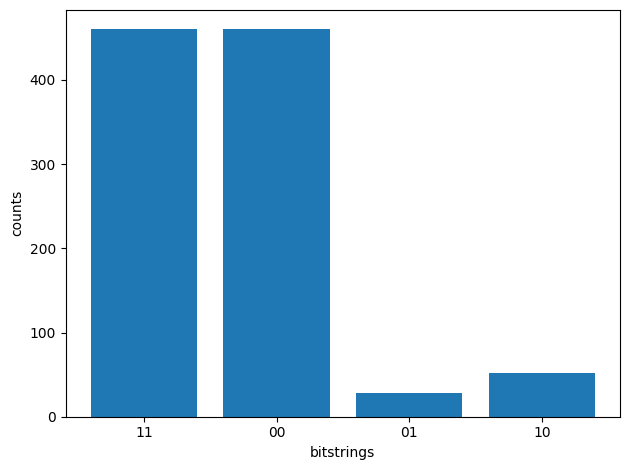

In [20]:
# recover quantum task
task_load = AwsQuantumTask(arn=rigetti_task_id)

# print status
status = task_load.state()
print("Status of (reconstructed) quantum task:", status)
print("\n")
# wait for job to complete
# terminal_states = ['COMPLETED', 'FAILED', 'CANCELLED']
if status == "COMPLETED":
    # get results
    rigetti_results = task_load.result()
    # print(rigetti_results)

    # get all metadata of submitted quantum task
    metadata = task_load.metadata()
    # example for metadata
    shots = metadata["shots"]
    machine = metadata["deviceArn"]
    # print example metadata
    print(f"{shots} shots taken on machine {machine}.\n")

    # get the compiled circuit
    print(
        "The compiled circuit is:\n",
        rigetti_results.additional_metadata.rigettiMetadata.compiledProgram,
    )

    # get measurement counts
    rigetti_counts = rigetti_results.measurement_counts
    print("Measurement counts:", rigetti_counts)

    # plot results: see effects of noise
    plt.bar(rigetti_counts.keys(), rigetti_counts.values())
    plt.xlabel("bitstrings")
    plt.ylabel("counts")
    plt.tight_layout()
    plt.savefig("rigetti.png", dpi=700)

elif status in ["FAILED", "CANCELLED"]:
    # print terminal message
    print("Your quantum task is in terminal status, but has not completed.")

else:
    # print current status
    print("Sorry, your quantum task is still being processed and has not been finalized yet.")

In [21]:
# recover quantum task
task_load = AwsQuantumTask(arn=ionq_task_id)

# print status
status = task_load.state()
print("Status of (reconstructed) quantum task:", status)

# wait for job to complete
# terminal_states = ['COMPLETED', 'FAILED', 'CANCELLED']
if status == "COMPLETED":
    # get results
    results = task_load.result()
    # print(rigetti_results)

    # get all metadata of submitted quantum task
    metadata = task_load.metadata()
    # example for metadata
    shots = metadata["shots"]
    machine = metadata["deviceArn"]
    # print example metadata
    print(f"{shots} shots taken on machine {machine}.")

    # get measurement counts
    counts = results.measurement_counts
    print("Measurement counts:", counts)

    # plot results: see effects of noise
    plt.bar(counts.keys(), counts.values())
    plt.xlabel("bitstrings")
    plt.ylabel("counts")
    plt.tight_layout()
    plt.savefig("bell_ionq.png", dpi=700)

elif status in ["FAILED", "CANCELLED"]:
    # print terminal message
    print("Your quantum task is in terminal status, but has not completed.")

else:
    # print current status
    print("Sorry, your quantum task is still being processed and has not been finalized yet.")

Status of (reconstructed) quantum task: QUEUED
Sorry, your quantum task is still being processed and has not been finalized yet.


We have successfully recovered the results associated with the quantum tasks that were queued up for the quantum hardware providers. Because of noise (decoherence) and other imperfections we cannot fully recover the exact results we have seen when using the classical simulator. To deal with that, in the fullness of time we will be able to use error correction techniques. As long as error correction is not available, it is important to benchmark our quantum results using classical simulators, whenever possible. 

---
# APPENDIX

Information on quantum task:
 AwsQuantumTask('id/taskArn':'arn:aws:braket:us-west-1:656977514066:quantum-task/7db7e4bd-7e58-4e8c-a351-1d2fedcc5036')
Status: QUEUED
Status: QUEUED
Status: QUEUED
Status: QUEUED
Status: QUEUED
Status: QUEUED
Status: COMPLETED
Status: COMPLETED
GateModelQuantumTaskResult(task_metadata=TaskMetadata(braketSchemaHeader=BraketSchemaHeader(name='braket.task_result.task_metadata', version='1'), id='arn:aws:braket:us-west-1:656977514066:quantum-task/7db7e4bd-7e58-4e8c-a351-1d2fedcc5036', shots=1000, deviceId='arn:aws:braket:us-west-1::device/qpu/rigetti/Cepheus-1-108Q', deviceParameters=RigettiDeviceParameters(braketSchemaHeader=BraketSchemaHeader(name='braket.device_schema.rigetti.rigetti_device_parameters', version='1'), paradigmParameters=GateModelParameters(braketSchemaHeader=BraketSchemaHeader(name='braket.device_schema.gate_model_parameters', version='1'), qubitCount=2, disableQubitRewiring=False)), createdAt='2026-04-15T23:47:04.588Z', endedAt='2026-04-15T

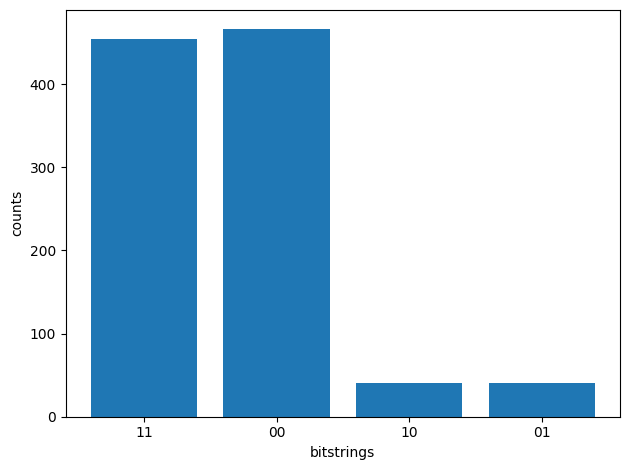

In [22]:
# set up device
rigetti = AwsDevice(Devices.Rigetti.Cepheus1108Q)

# run circuit
task = rigetti.run(bell, shots=1000)
print("Information on quantum task:\n", task)
print("==================================" * 2)

# get status of submitted quantum task
status = task.state()

# wait for job to complete
terminal_states = ["COMPLETED", "FAILED", "CANCELLED"]
while status not in terminal_states:
    status = task.state()
    print("Status:", status)
    # time.sleep(60)

print("Status:", status)

# get results
rigetti_results = task.result()
print(rigetti_results)

# get measurement counts
rigetti_counts = rigetti_results.measurement_counts
print(rigetti_counts)

# plot results: see effects of noise
plt.bar(rigetti_counts.keys(), rigetti_counts.values())
plt.xlabel("bitstrings")
plt.ylabel("counts")
plt.tight_layout()
plt.savefig("rigetti2.png", dpi=700)

In [23]:
print("Quantum Task Summary")
print(t.quantum_tasks_statistics())
print(
    "Note: Charges shown are estimates based on your Amazon Braket simulator and quantum processing unit (QPU) task usage. Estimated charges shown may differ from your actual charges. Estimated charges do not factor in any discounts or credits, and you may experience additional charges based on your use of other services such as Amazon Elastic Compute Cloud (Amazon EC2).",
)
print(
    f"Estimated cost to run this example: {t.qpu_tasks_cost() + t.simulator_tasks_cost():.2f} USD",
)

Quantum Task Summary
{<_Rigetti.Cepheus1108Q: 'arn:aws:braket:us-west-1::device/qpu/rigetti/Cepheus-1-108Q'>: {'shots': 2100, 'tasks': {'COMPLETED': 2, 'QUEUED': 1}}, <_IonQ.Forte1: 'arn:aws:braket:us-east-1::device/qpu/ionq/Forte-1'>: {'shots': 100, 'tasks': {'QUEUED': 1}}, <_IQM.Garnet: 'arn:aws:braket:eu-north-1::device/qpu/iqm/Garnet'>: {'shots': 1000, 'tasks': {'QUEUED': 1}}}
Note: Charges shown are estimates based on your Amazon Braket simulator and quantum processing unit (QPU) task usage. Estimated charges shown may differ from your actual charges. Estimated charges do not factor in any discounts or credits, and you may experience additional charges based on your use of other services such as Amazon Elastic Compute Cloud (Amazon EC2).
Estimated cost to run this example: 11.84 USD
